<b>MultiModal RAG App for Video Processing With LlamaIndex and LanceDB</b>

Steps Need to follow:
1. Download video from YouTube, process and store it.
2. Build Multi-Modal index and vector store for both texts and images.
3. Retrieve relevant images and context, use both to augment the prompt.
4. Using GPT4V for reasoning the correlations between the input query and augmented data and generating final response.

In [1]:
# %pip install llama-index-vector-stores-lancedb
# %pip install llama-index-multi-modal-llms-openai
# %pip install llama-index-embeddings-clip
# %pip install git+https://github.com/openai/CLIP.git
# !pip install llama-index-readers-file

In [2]:
# %pip install llama_index
# %pip install -U openai-whisper

In [3]:
# %pip install lancedb
# %pip install moviepy
# %pip install pytube
# %pip install pydub
# %pip install SpeechRecognition
# %pip install ffmpeg-python
# %pip install soundfile
# %pip install torch torchvision
# %pip install matplotlib scikit-image
# %pip install ftfy regex tqdm

**ffmpeg**-library enables you to use FFmpeg in Python to manipulate various media files for different purposes like building comprehensive multimedia applications, preprocessing media files.

**MoviePy** is a Python library for video editing, enabling cutting, concatenations, title insertions, video compositing, and effects like animations or color grading.

**Pytube** is a Python library used for downloading videos from YouTube. It supports downloading in various formats, resolutions, and also direct audio extraction.

**Pydub** is a Python library for audio manipulation, enabling easy loading, editing, and exporting of audio files in various formats with minimal code.

The **SpeechRecognition** library in Python allows you to convert spoken language into text using various engines and APIs, such as Google Speech Recognition, IBM Speech to Text, etc.

**SoundFile** is a Python library for reading from and writing to audio files, supporting many formats through the libsndfile library, ideal for high-quality audio processing.

**FTFY (Fix Text For You)** is a Python library that fixes broken Unicode text and mojibake (garbled text due to encoding issues), making text legible again.

**OpenAI Whisper** is a robust, multilingual speech recognition model developed by OpenAI. It converts speech into text and supports various languages with high accuracy.

**pprint** is a Python module that provides a capability to "pretty-print" complex data structures in a well-formatted and more readable way than the basic print function.

In [4]:
from moviepy import VideoFileClip
from pathlib import Path
import speech_recognition as sr
# from pytube import YouTube  
from pytubefix import YouTube
from pytubefix.cli import on_progress
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
# import os
# import ollama

# def model_call():
#     path = "rollsroyse.jpg"

#     if not os.path.exists(path):
#         print(f"Error: Image not found at {path}")
#         return  
    
#     response = ollama.chat(
#         model="gemma3:4b",
#         messages=[
#             {
#                 "role": "user",
#                 "content": "Identify the main objects in this image and describe the setting.",
#                 # Changed key from 'image' to 'images'
#                 "images": [path] 
#             }
#         ]
#     )
#     print(response['message']['content'])

# model_call()

In [6]:
# pip install -U transformers accelerate bitsandbytes sentencepiece

In [7]:
video_url = "https://youtu.be/3dhcmeOTZ_Q"
output_video_path = "content/video_data/"

In [8]:
output_folder = "content/mixed_data/"
output_audio_path = "content/mixed_data/output_audio.wav"

In [9]:
filepath = output_video_path + "input_vid.mp4"
print(filepath)

content/video_data/input_vid.mp4


In [10]:
def download_video(video_url, output_path):
    yt = YouTube(video_url, on_progress_callback=on_progress)
    
    print("Youtube output:-\n")
    print(yt)
    
    metadata = {"Author": yt.author, "Title": yt.title, "Views": yt.views}
    yt.streams.get_highest_resolution().download(output_path=output_path, filename="input_vid.mp4")
        
    return metadata

In [11]:
def video_to_images(video_path,output_folder):
    clip=VideoFileClip(video_path)
    clip.write_images_sequence(
        os.path.join(output_folder,"frame%04d.png"),fps=0.2
    )

In [12]:
def video_to_audio(video_path,output_audio_path):
    clip=VideoFileClip(video_path)
    audio=clip.audio
    audio.write_audiofile(output_audio_path)

In [13]:
import whisper
import os
def audio_to_text(audio_file):
    # 1. Load the model 
    # Options: 'tiny', 'base', 'small', 'medium', 'large'
    # Since you have Intel UHD, 'base' or 'small' will be the fastest.
    print("Loading Whisper model...")
    model = whisper.load_model("base", device="cpu") 

    # 2. Path to your audio file
    # audio_file = "content/mixed_data/output_audio.wav"

    if not os.path.exists(audio_file):
        print(f"File {audio_file} not found!")
    else:
        print("Transcribing... (this may take a few minutes)")
        # 3. Run the transcription
        result = model.transcribe(audio_file, verbose=True)

        # 4. Print the result
        print("\n--- Transcription ---")
        print(result["text"])
        return result

In [14]:
video_url

'https://youtu.be/3dhcmeOTZ_Q'

In [15]:
output_video_path

'content/video_data/'

In [16]:
metadata_vid = download_video(video_url,output_video_path)

Youtube output:-

<pytubefix.__main__.YouTube object: videoId=3dhcmeOTZ_Q>


In [17]:
# !pip uninstall -y pytube
# %pip install pytubefix
# %pip install -U openai-whisper

In [18]:
metadata_vid

{'Author': '3-Minute Data Science',
 'Title': 'Linear Regression in 3 Minutes',
 'Views': 250190}

In [19]:
filepath

'content/video_data/input_vid.mp4'

In [20]:
output_folder

'content/mixed_data/'

In [21]:
video_to_images(filepath,output_folder)

In [22]:
output_audio_path

'content/mixed_data/output_audio.wav'

In [23]:
video_to_audio(filepath,output_audio_path)

MoviePy - Writing audio in content/mixed_data/output_audio.wav


MoviePy - Done.


In [24]:
text_data = audio_to_text(output_audio_path)

Loading Whisper model...
Transcribing... (this may take a few minutes)


c:\Python313\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Detecting language using up to the first 30 seconds. Use `--language` to specify the language
Detected language: English
[00:00.000 --> 00:20.720]  Lenny regression is a statistical technique for modeling the relationship between an output
[00:20.720 --> 00:23.800]  variable and one or more input variables.
[00:23.800 --> 00:28.280]  In layman's terms, think of it as fitting a line through some data points as shown here,
[00:28.280 --> 00:32.400]  so you can make predictions on unknown data, assuming there is a linear relationship
[00:32.400 --> 00:35.560]  between the variables.
[00:35.560 --> 00:40.400]  You might be familiar with the linear function y equals mx plus b, where y is the output
[00:40.400 --> 00:43.600]  variable, also called the dependent variable.
[00:43.600 --> 00:47.800]  You may also see expressed as f of x, the function of the input variable.
[00:47.800 --> 00:54.360]  x on the other hand, would serve as the input variable, also called the independent variable.
[0

In [25]:
text_data['text']

" Lenny regression is a statistical technique for modeling the relationship between an output variable and one or more input variables. In layman's terms, think of it as fitting a line through some data points as shown here, so you can make predictions on unknown data, assuming there is a linear relationship between the variables. You might be familiar with the linear function y equals mx plus b, where y is the output variable, also called the dependent variable. You may also see expressed as f of x, the function of the input variable. x on the other hand, would serve as the input variable, also called the independent variable. And slightly you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively. So what do the m and b coefficients do? The m or beta 1 coefficient controls the slope of the line, the b or the beta 0 controls the intercept of the line, in machine learning we also know it as the bias. These two coefficients are what we are solving for in linear regr

In [26]:
with open(output_folder+"output_text.txt", "w") as f:
    f.write(text_data['text'])
print("\nSaved to output_text.txt")


Saved to output_text.txt


In [27]:
from llama_index.core import SimpleDirectoryReader, StorageContext, Settings
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.vector_stores.lancedb import LanceDBVectorStore
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.clip import ClipEmbedding

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
# image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

In [29]:
# storage_context=StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

In [30]:
output_folder

'content/mixed_data/'

In [31]:
# documents=SimpleDirectoryReader(output_folder).load_data()

In [32]:
# index = MultiModalVectorStoreIndex.from_documents(documents,storage_context=storage_context)

# What does MultiModalVectorStoreIndex do?

In a standard RAG application, you have a regular `VectorStoreIndex` that takes **text documents**, converts them into vector embeddings, and stores them so they can be searched later. 

`MultiModalVectorStoreIndex` extends this so it can handle **multiple types of data at once** (specifically Text and Images). 

**Key functions:**
1. **Dual Indexing**: It creates and stores vector embeddings for both text documents and images independently using separate models (e.g., OpenAI's text embedding model for text, and CLIP embeddings for images).
2. **Unified Retrieval**: When you query the index, it searches through *both* the text vectors and the image vectors simultaneously to find the most relevant context.
3. **Multi-Modal Synthesis**: It passes the retrieved text chunks and retrieved images to a Multi-Modal LLM (like GPT-4V or Gemini) to synthesize a final answer based on all available modalities.


In [33]:
# %pip install ImageHash

### Filtering Duplicate Video Frames with Perceptual Hashing (pHash)

**Why are we doing this?**
When extracting frames from a video every few seconds, we often capture long periods where nothing visually changes (e.g., a presenter standing still or a static slide). Processing identical frames through a Vision API wastes compute time, memory, and API costs without adding any new information for our RAG index.

**What does this code do?**
We use **ImageHash** to compute a "Perceptual Hash" (pHash) for each frame in chronological order. 
1. The code calculates a unique fingerprint (hash) based on the visual contents of an image, ignoring minor compression artifacts. 
2. It compares the current frame to the last unique frame we kept. 
3. If the "distance" between the hashes is below our threshold (meaning they look identical to the human eye), the frame is deleted. 
4. If they look different enough, the new frame is kept and becomes the new baseline for comparison.


In [34]:
import os
from PIL import Image
import imagehash

def remove_duplicate_frames(folder_path, threshold=5):
    """
    Scans a folder for images and deletes perceptual duplicates.
    - threshold: How strict the comparison is. 
      (0 = exactly identical, 5 = minor compression differences allowed, 10+ = very aggressive)
    """
    print(f"Scanning {folder_path} for duplicate frames...")
    
    # Get all .png files and sort them so we process them in temporal order
    files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    files.sort() 
    
    if not files:
        print("No images found.")
        return

    # Keep track of the hash of the last unique image we decided to keep
    # We initialize it with the hash of the very first image
    first_image_path = os.path.join(folder_path, files[0])
    last_kept_hash = imagehash.phash(Image.open(first_image_path))
    
    deleted_count = 0
    
    # Start checking from the second image onwards
    for filename in files[1:]:
        filepath = os.path.join(folder_path, filename)
        
        # Calculate the perceptual hash of the current image
        current_hash = imagehash.phash(Image.open(filepath))
        
        # The difference (-) between two image hashes is the "Hamming distance"
        # If the distance is below our threshold, they are visually duplicates
        if current_hash - last_kept_hash < threshold:
            os.remove(filepath)
            deleted_count += 1
            # We DONT update last_kept_hash, so the next image is compared to the original one
        else:
            # It's a sufficiently new/different frame; keep it and update our baseline
            last_kept_hash = current_hash
            
    print(f"Done! Deleted {deleted_count} duplicate frames.")
    print(f"Remaining frames: {len(files) - deleted_count}")

# Run the function on your folder
remove_duplicate_frames(output_folder, threshold=5)


Scanning content/mixed_data/ for duplicate frames...
Done! Deleted 14 duplicate frames.
Remaining frames: 33


In [35]:
Settings.embed_model = HuggingFaceEmbedding(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# 2. Set the IMAGE model
image_embed_model = ClipEmbedding(model_name="ViT-B/32")

# 3. Setup LanceDB
text_store = LanceDBVectorStore(uri="lancedb", table_name="text_collection")
image_store = LanceDBVectorStore(uri="lancedb", table_name="image_collection")

storage_context = StorageContext.from_defaults(
    vector_store=text_store, 
    image_store=image_store
)

# 4. Load your data (folder containing your wav transcript and images)
print("Loading documents...")
documents = SimpleDirectoryReader(
    output_folder, 
    required_exts=[".txt", ".png"] # <-- This is the fix!
).load_data(show_progress=True)

# 5. Build the Index (100% Free, no API calls)
print("Building index (this will take a while for images)...")
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    image_embed_model=image_embed_model,
    show_progress=True # <-- Added progress bar here!
)

print("Success! Your local index is ready.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8980.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading documents...


Loading files: 100%|██████████| 34/34 [00:00<00:00, 286.27it/s]

Building index (this will take a while for images)...



Generating image embeddings: 100%|██████████| 33/33 [00:02<00:00, 16.20it/s]

Success! Your local index is ready.


### There are two different ways to "embed" a [.wav](cci:7://file:///c:/Users/Manas%20tiwari/Desktop/RAG/Multi-modal%20RAG-Video%20Processing/content/mixed_data/output_audio.wav:0:0-0:0) file, and they serve different purposes.

#### Option 1: Embedding the "Sound" Directly (Audio Search)
If you want to search for audio files that **sound** similar (e.g., *"Find other clips with this same background music"* or *"Find recordings with this person's voice"*), you use a model like **CLAP** or **ImageBind**. This bypasses transcription entirely and turns the raw audio waves into a vector.

* **Pros:** Captures tone, emotion, background noise, and music.
* **Cons:** Doesn't "read" the words as well as a text model does.

#### Option 2: The "LlamaIndex" Way (Semantic Search)
If you want to search for the **meaning** of what was said, the best practice is to transcribe first (using Whisper) and then embed the text. This is what LlamaIndex is built for.

> **Note:** Even though it feels like an extra step, **"Text-from-Audio"** embeddings are currently much more accurate for finding information than **"Raw Audio"** embeddings.


In [36]:
retriever_engine=index.as_retriever(similarity_top_k=3, image_similarity_top_k=5)

In [37]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [38]:
def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text
     

In [39]:
query_str="can you tell me what is linear regression and equation of linear regression?"

In [40]:
img,text=retrieve(retriever_engine,query_str)

2026-03-16 13:11:30,375 - INFO - query_type :, vector


2026-03-16 13:11:30,470 - INFO - query_type :, vector


**Node ID:** 875e5e17-7392-4da0-b115-d16ca15b88ca<br>**Similarity:** 0.2973701059818268<br>**Text:** Lenny regression is a statistical technique for modeling the relationship between an output variable and one or more input variables. In layman's terms, think of it as fitting a line through some d...<br>

**Node ID:** 30fe5a16-cbe2-4fa5-9718-852243eee08d<br>**Similarity:** 0.2973701059818268<br>**Text:** Lenny regression is a statistical technique for modeling the relationship between an output variable and one or more input variables. In layman's terms, think of it as fitting a line through some d...<br>

In [41]:
import matplotlib.pyplot as plt
def plot_images(images_path):
  images_shown = 0
  plt.figure(figsize=(16, 9))
  for img_path in images_path:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 5:
                break

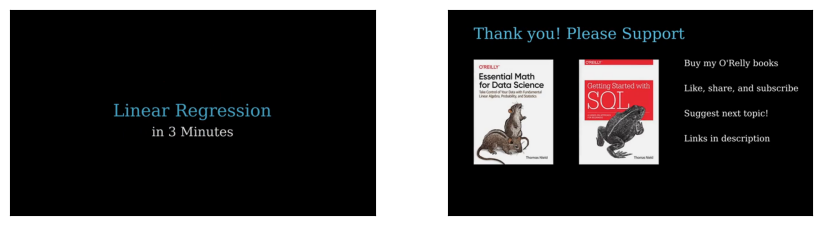

In [42]:
plot_images(img)

In [43]:
img

['c:\\Users\\Manas tiwari\\Desktop\\RAG\\Multi-modal RAG-Video Processing\\content\\mixed_data\\frame0003.png',
 'c:\\Users\\Manas tiwari\\Desktop\\RAG\\Multi-modal RAG-Video Processing\\content\\mixed_data\\frame0040.png']

In [44]:
import json

# 1. Define your components first
metadata_str = json.dumps(metadata_vid)
context_str = "\n\n".join(text)

# 2. Then build the prompt
prompt = f"""You are an intelligent assistant provided with relevant textual context and image frames extracted from a video.
Please answer the user's query comprehensively based ONLY on the provided context and images.
-------------
CONTEXT:
{context_str}
METADATA: {metadata_str}
-------------
QUERY: {query_str}
"""


In [45]:
metadata_str

'{"Author": "3-Minute Data Science", "Title": "Linear Regression in 3 Minutes", "Views": 250190}'

In [46]:
print(f"\nSending context to Gemma 3... (Found {len(text)} text chunks and {len(img)} image frames)")


Sending context to Gemma 3... (Found 2 text chunks and 2 image frames)


In [47]:
import ollama  

response = ollama.chat(
    model="gemma3:4b",
    messages=[
       {
        'role':'user',
        'content': prompt,
        'images':img if img else None
        }
    ]
)

response['message']['content']

2026-03-16 13:23:53,421 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


"Here’s a breakdown of linear regression and its equation, based on the provided context:\n\n**What is Linear Regression?**\n\nLinear regression is a statistical technique used to model the relationship between an output variable (y) and one or more input variables (x).  Essentially, it’s about fitting a line through a set of data points. This line allows you to make predictions about the output variable (y) based on the input variable(s) (x), assuming a linear relationship exists.\n\n**The Equation of a Linear Regression Line**\n\nThe equation of a linear regression line is:\n\n*   **y = mx + b**\n\n    *   **y:** The output variable (dependent variable) – what you're trying to predict.\n    *   **x:** The input variable (independent variable) – the factor you're using to make the prediction.\n    *   **m:** The slope of the line – represents the change in ‘y’ for every one unit change in ‘x’.\n    *   **b:** The y-intercept – the value of ‘y’ when ‘x’ is equal to zero.\n\n**Coefficie

In [48]:
pprint(response['message']['content'])

('Here’s a breakdown of linear regression and its equation, based on the '
 'provided context:\n'
 '\n'
 '**What is Linear Regression?**\n'
 '\n'
 'Linear regression is a statistical technique used to model the relationship '
 'between an output variable (y) and one or more input variables (x).  '
 'Essentially, it’s about fitting a line through a set of data points. This '
 'line allows you to make predictions about the output variable (y) based on '
 'the input variable(s) (x), assuming a linear relationship exists.\n'
 '\n'
 '**The Equation of a Linear Regression Line**\n'
 '\n'
 'The equation of a linear regression line is:\n'
 '\n'
 '*   **y = mx + b**\n'
 '\n'
 "    *   **y:** The output variable (dependent variable) – what you're trying "
 'to predict.\n'
 "    *   **x:** The input variable (independent variable) – the factor you're "
 'using to make the prediction.\n'
 '    *   **m:** The slope of the line – represents the change in ‘y’ for '
 'every one unit change in ‘x’.\n'
